<a href="https://colab.research.google.com/github/ojrestrepom/tesis-registro-multimodal-temporal/blob/main/notebooks/Notebook_1_Exploracion_Inicial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

BASE = Path('/content/drive/MyDrive/Tesis Maestría')
DATA_ROOT = BASE / 'Datos_HSI'

for item in DATA_ROOT.iterdir():
    print(item)

/content/drive/MyDrive/Tesis Maestría/Datos_HSI/Registradas_Procesadas


In [ ]:
from pathlib import Path

BASE = Path('/content/drive/MyDrive/Tesis Maestría')
DATA_ROOT = BASE / 'Datos_HSI'
DATA_DIR = DATA_ROOT / 'Registradas_Procesadas'

print(f'Existe: {DATA_DIR.exists()}')
print(f'Es carpeta: {DATA_DIR.is_dir()}')

Existe: True
Es carpeta: True


In [ ]:
!pip -q install spectral

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import spectral
import numpy as np

FOLIOLO = 3
CARA = 'haz'
DIA = 3

HDR = DATA_DIR / f'foliolo{FOLIOLO}' / CARA / f'foliolo{FOLIOLO}_{CARA}_a{DIA}.hdr'

print(HDR)
print(f'HDR existe: {HDR.exists()}')
print(f'IMG existe: {HDR.with_suffix(".img").exists()}')

/content/drive/MyDrive/Tesis Maestría/Datos_HSI/Registradas_Procesadas/foliolo3/haz/foliolo3_haz_a3.hdr
HDR existe: True
IMG existe: True


In [ ]:
img = spectral.open_image(str(HDR))

print('Dimensiones:', img.shape)
print('Tipo:', img.dtype)
print('Interleave:', img.metadata.get('interleave'))
print('Bandas:', img.metadata.get('bands'))
print('Longitudes de onda:', len(img.metadata.get('wavelength', [])))

Dimensiones: (327, 226, 111)
Tipo: <f4
Interleave: bip
Bandas: 111
Longitudes de onda: 111


In [ ]:
wavelengths = np.array(img.metadata.get('wavelength', []), dtype=float)

print(f'Primera longitud de onda: {wavelengths[0]:.2f} nm')
print(f'Última longitud de onda:  {wavelengths[-1]:.2f} nm')
print(f'Número de bandas:         {len(wavelengths)}')

print('\nPrimeras 10:')
print(np.round(wavelengths[:10], 2))

print('\nÚltimas 10:')
print(np.round(wavelengths[-10:], 2))

Primera longitud de onda: 401.59 nm
Última longitud de onda:  998.17 nm
Número de bandas:         111

Primeras 10:
[401.59 406.82 412.06 417.31 422.55 427.8  433.06 438.32 443.58 448.84]

Últimas 10:
[948.98 954.59 960.2  965.82 971.44 977.06 982.68 988.31 993.94 998.17]


In [ ]:
cube = np.asarray(img.load())

print('Shape:', cube.shape)
print('dtype:', cube.dtype)
print('Mínimo:', np.nanmin(cube))
print('Máximo:', np.nanmax(cube))
print('Media:', np.nanmean(cube))
print('NaN:', np.isnan(cube).sum())

Shape: (327, 226, 111)
dtype: float32
Mínimo: 0.0
Máximo: 0.6141702
Media: 0.09470036
NaN: 0


In [ ]:
def banda_mas_cercana(wavelengths, objetivo):
    idx = np.argmin(np.abs(wavelengths - objetivo))
    return idx, wavelengths[idx]

for nombre, objetivo in [('R', 650), ('G', 550), ('B', 450)]:
    idx, wl = banda_mas_cercana(wavelengths, objetivo)
    print(f'{nombre}: banda {idx} → {wl:.2f} nm')

R: banda 47 → 651.64 nm
G: banda 28 → 549.58 nm
B: banda 9 → 448.84 nm


In [ ]:
def normalizar_banda(banda, p_low=2, p_high=98):
    lo, hi = np.percentile(banda, [p_low, p_high])
    if hi <= lo:
        return np.zeros_like(banda)

    banda = (banda - lo) / (hi - lo)
    return np.clip(banda, 0, 1)

def crear_pseudorgb(cube, wavelengths):
    idx_r = np.argmin(np.abs(wavelengths - 650))
    idx_g = np.argmin(np.abs(wavelengths - 550))
    idx_b = np.argmin(np.abs(wavelengths - 450))

    r = normalizar_banda(cube[:, :, idx_r])
    g = normalizar_banda(cube[:, :, idx_g])
    b = normalizar_banda(cube[:, :, idx_b])

    return np.dstack([r, g, b])

In [ ]:
import spectral
import numpy as np

FOLIOLO = 3
CARA = 'haz'
DIAS = [3, 8, 13]

imagenes = {}

for dia in DIAS:
    hdr = DATA_DIR / f'foliolo{FOLIOLO}' / CARA / f'foliolo{FOLIOLO}_{CARA}_a{dia}.hdr'
    envi = spectral.open_image(str(hdr))
    cube = np.asarray(envi.load())

    wl = np.array(envi.metadata['wavelength'], dtype=float)
    rgb = crear_pseudorgb(cube, wl)

    imagenes[dia] = {
        'cube': cube,
        'wavelengths': wl,
        'rgb': rgb
    }

    print(f'a{dia}: {cube.shape}')

a3: (327, 226, 111)
a8: (327, 226, 111)
a13: (327, 226, 111)


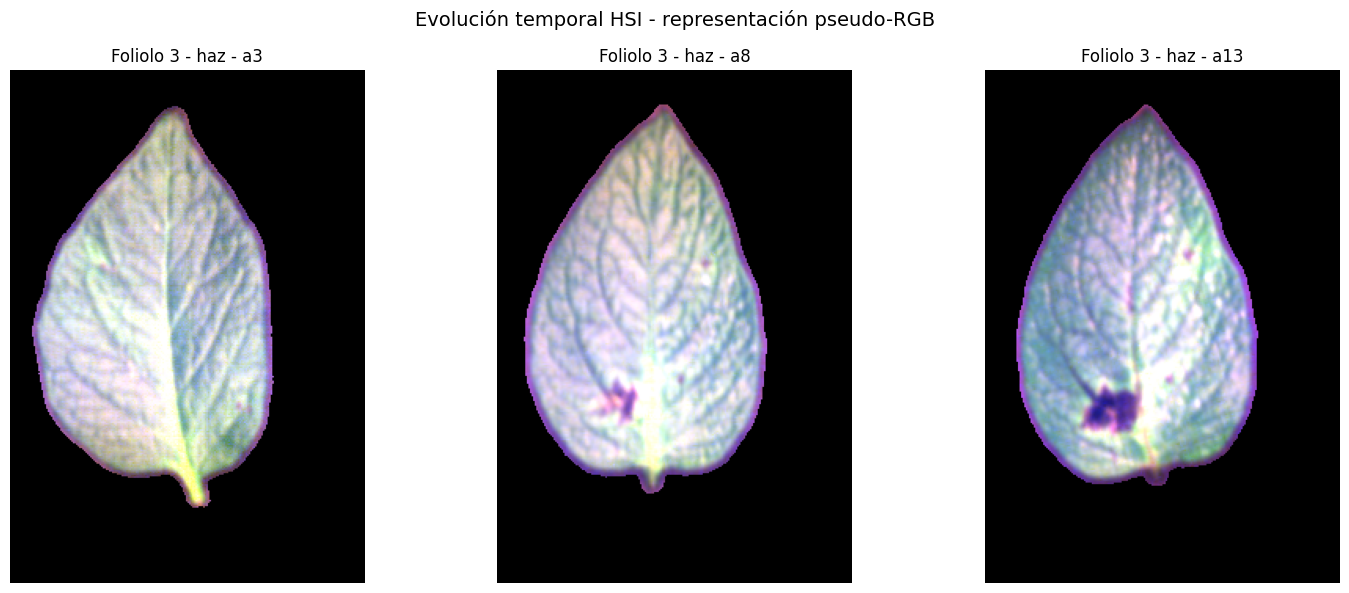

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, dia in zip(axes, DIAS):
    ax.imshow(imagenes[dia]['rgb'])
    ax.set_title(f'Foliolo {FOLIOLO} - haz - a{dia}')
    ax.axis('off')

plt.suptitle('Evolución temporal HSI - representación pseudo-RGB', fontsize=14)
plt.tight_layout()
plt.show()

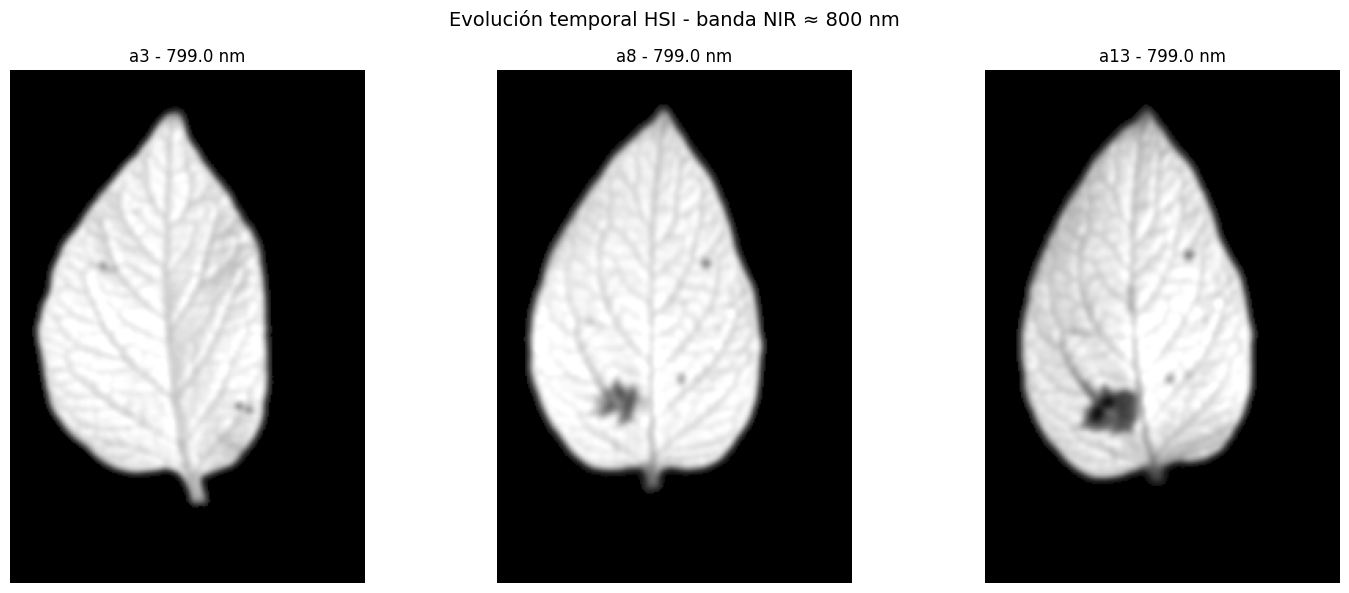

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for ax, dia in zip(axes, DIAS):
    cube = imagenes[dia]['cube']
    wl = imagenes[dia]['wavelengths']

    idx = np.argmin(np.abs(wl - 800))
    banda = normalizar_banda(cube[:, :, idx])

    ax.imshow(banda, cmap='gray')
    ax.set_title(f'a{dia} - {wl[idx]:.1f} nm')
    ax.axis('off')

plt.suptitle('Evolución temporal HSI - banda NIR ≈ 800 nm', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
!pip -q install SimpleITK

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 15.1 MB/s eta 0:00:00


In [ ]:
import SimpleITK as sitk

WL_OBJETIVO = 800

def obtener_banda(imagen, wl_objetivo=800):
    cube = imagen['cube']
    wl = imagen['wavelengths']
    idx = np.argmin(np.abs(wl - wl_objetivo))
    return cube[:, :, idx].astype(np.float32), idx, wl[idx]

fixed_np, idx_f, wl_f = obtener_banda(imagenes[3], WL_OBJETIVO)
moving_np, idx_m, wl_m = obtener_banda(imagenes[8], WL_OBJETIVO)

print(f'Fixed  a3: banda {idx_f}, {wl_f:.2f} nm, {fixed_np.shape}')
print(f'Moving a8: banda {idx_m}, {wl_m:.2f} nm, {moving_np.shape}')

Fixed  a3: banda 74, 798.97 nm, (327, 226)
Moving a8: banda 74, 798.97 nm, (327, 226)


In [ ]:
def normalizar_registro(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, [p_low, p_high])
    img = np.clip(img, lo, hi)

    if hi > lo:
        img = (img - lo) / (hi - lo)

    return img.astype(np.float32)

fixed_np = normalizar_registro(fixed_np)
moving_np = normalizar_registro(moving_np)

In [ ]:
fixed = sitk.GetImageFromArray(fixed_np)
moving = sitk.GetImageFromArray(moving_np)

In [ ]:
print('Size:', fixed.GetSize())
print('Spacing:', fixed.GetSpacing())
print('Origin:', fixed.GetOrigin())
print('Direction:', fixed.GetDirection())

Size: (226, 327)
Spacing: (1.0, 1.0)
Origin: (0.0, 0.0)
Direction: (1.0, 0.0, 0.0, 1.0)


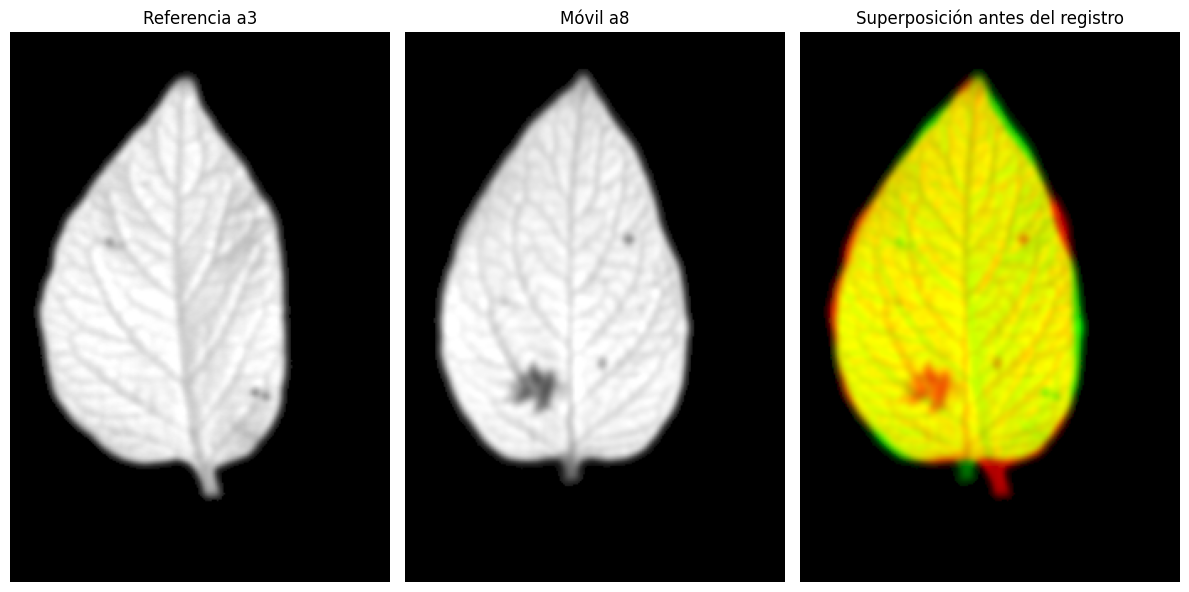

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(fixed_np, cmap='gray')
axes[0].set_title('Referencia a3')

axes[1].imshow(moving_np, cmap='gray')
axes[1].set_title('Móvil a8')

overlay = np.dstack([
    fixed_np,
    moving_np,
    np.zeros_like(fixed_np)
])

axes[2].imshow(overlay)
axes[2].set_title('Superposición antes del registro')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
registration = sitk.ImageRegistrationMethod()

# Métrica
registration.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
registration.SetMetricSamplingStrategy(registration.RANDOM)
registration.SetMetricSamplingPercentage(0.20)

# Interpolación
registration.SetInterpolator(sitk.sitkLinear)

# Transformación rígida inicial
initial_transform = sitk.CenteredTransformInitializer(
    fixed,
    moving,
    sitk.Euler2DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

registration.SetInitialTransform(initial_transform, inPlace=False)

# Optimizador
registration.SetOptimizerAsGradientDescent(
    learningRate=1.0,
    numberOfIterations=200,
    convergenceMinimumValue=1e-6,
    convergenceWindowSize=10
)

registration.SetOptimizerScalesFromPhysicalShift()

# Multi-resolución
registration.SetShrinkFactorsPerLevel([4, 2, 1])
registration.SetSmoothingSigmasPerLevel([2, 1, 0])
registration.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

rigid_transform = registration.Execute(fixed, moving)

print('Métrica final:', registration.GetMetricValue())
print('Iteraciones:', registration.GetOptimizerIteration())
print('Motivo de parada:', registration.GetOptimizerStopConditionDescription())

Métrica final: -0.7124032367434442
Iteraciones: 12
Motivo de parada: GradientDescentOptimizerv4Template: Convergence checker passed at iteration 12.


In [ ]:
moving_rigid = sitk.Resample(
    moving,
    fixed,
    rigid_transform,
    sitk.sitkLinear,
    0.0,
    moving.GetPixelID()
)

rigid_np = sitk.GetArrayFromImage(moving_rigid)

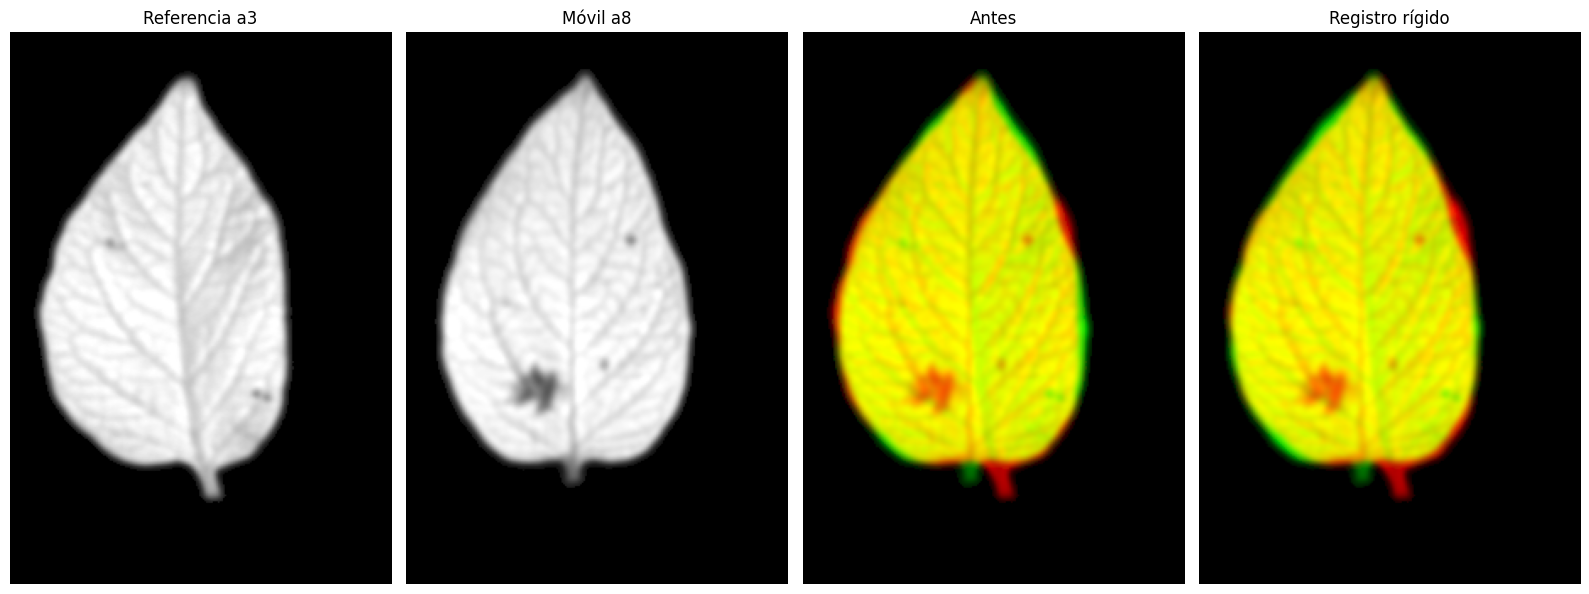

In [ ]:
overlay_antes = np.dstack([
    fixed_np,
    moving_np,
    np.zeros_like(fixed_np)
])

overlay_rigido = np.dstack([
    fixed_np,
    rigid_np,
    np.zeros_like(fixed_np)
])

fig, axes = plt.subplots(1, 4, figsize=(16, 6))

axes[0].imshow(fixed_np, cmap='gray')
axes[0].set_title('Referencia a3')

axes[1].imshow(moving_np, cmap='gray')
axes[1].set_title('Móvil a8')

axes[2].imshow(overlay_antes)
axes[2].set_title('Antes')

axes[3].imshow(overlay_rigido)
axes[3].set_title('Registro rígido')

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
print(rigid_transform)

itk::simple::CompositeTransform
 CompositeTransform (0x37fd63e0)
   RTTI typeinfo:   itk::CompositeTransform<double, 2u>
   Reference Count: 1
   Modified Time: 43492
   Debug: Off
   Object Name: 
   Observers: 
     none
   TransformQueue: 
   >>>>>>>>>
   Euler2DTransform (0x3929fe20)
     RTTI typeinfo:   itk::Euler2DTransform<double>
     Reference Count: 1
     Modified Time: 43338
     Debug: Off
     Object Name: 
     Observers: 
       none
     Matrix: 
       0.999999 -0.00121218 
       0.00121218 0.999999 
     Offset: [2.70178, -0.0261945]
     Center: [112.5, 163]
     Translation: [2.50411, 0.110056]
     Inverse: 
       0.999999 0.00121218 
       -0.00121218 0.999999 
     Singular: 0
     Angle: 0.00121218
   TransformsToOptimizeFlags: 
           1 
   TransformsToOptimizeQueue: 
   PreviousTransformsToOptimizeUpdateTime: 0



In [ ]:
euler = rigid_transform.GetNthTransform(0)

print('Ángulo:', np.degrees(euler.GetAngle()), 'grados')
print('Traslación:', euler.GetTranslation())
print('Centro:', euler.GetCenter())

Ángulo: 0.06945272380567959 grados
Traslación: (2.504108817205335, 0.11005579294329904)
Centro: (112.5, 163.0)


In [ ]:
affine_initial = sitk.AffineTransform(2)
affine_initial.SetCenter(euler.GetCenter())
affine_initial.SetMatrix(euler.GetMatrix())
affine_initial.SetTranslation(euler.GetTranslation())

In [ ]:
registration_affine = sitk.ImageRegistrationMethod()

registration_affine.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
registration_affine.SetMetricSamplingStrategy(registration_affine.RANDOM)
registration_affine.SetMetricSamplingPercentage(0.20)

registration_affine.SetInterpolator(sitk.sitkLinear)

registration_affine.SetOptimizerAsGradientDescent(
    learningRate=0.5,
    numberOfIterations=300,
    convergenceMinimumValue=1e-6,
    convergenceWindowSize=10
)

registration_affine.SetOptimizerScalesFromPhysicalShift()

registration_affine.SetShrinkFactorsPerLevel([4, 2, 1])
registration_affine.SetSmoothingSigmasPerLevel([2, 1, 0])
registration_affine.SmoothingSigmasAreSpecifiedInPhysicalUnitsOn()

registration_affine.SetInitialTransform(affine_initial, inPlace=False)

affine_transform = registration_affine.Execute(fixed, moving)

print('Métrica final:', registration_affine.GetMetricValue())
print('Iteraciones:', registration_affine.GetOptimizerIteration())
print('Motivo de parada:', registration_affine.GetOptimizerStopConditionDescription())

Métrica final: -0.7184301668994836
Iteraciones: 14
Motivo de parada: GradientDescentOptimizerv4Template: Convergence checker passed at iteration 14.


In [ ]:
moving_affine = sitk.Resample(
    moving,
    fixed,
    affine_transform,
    sitk.sitkLinear,
    0.0,
    moving.GetPixelID()
)

affine_np = sitk.GetArrayFromImage(moving_affine)

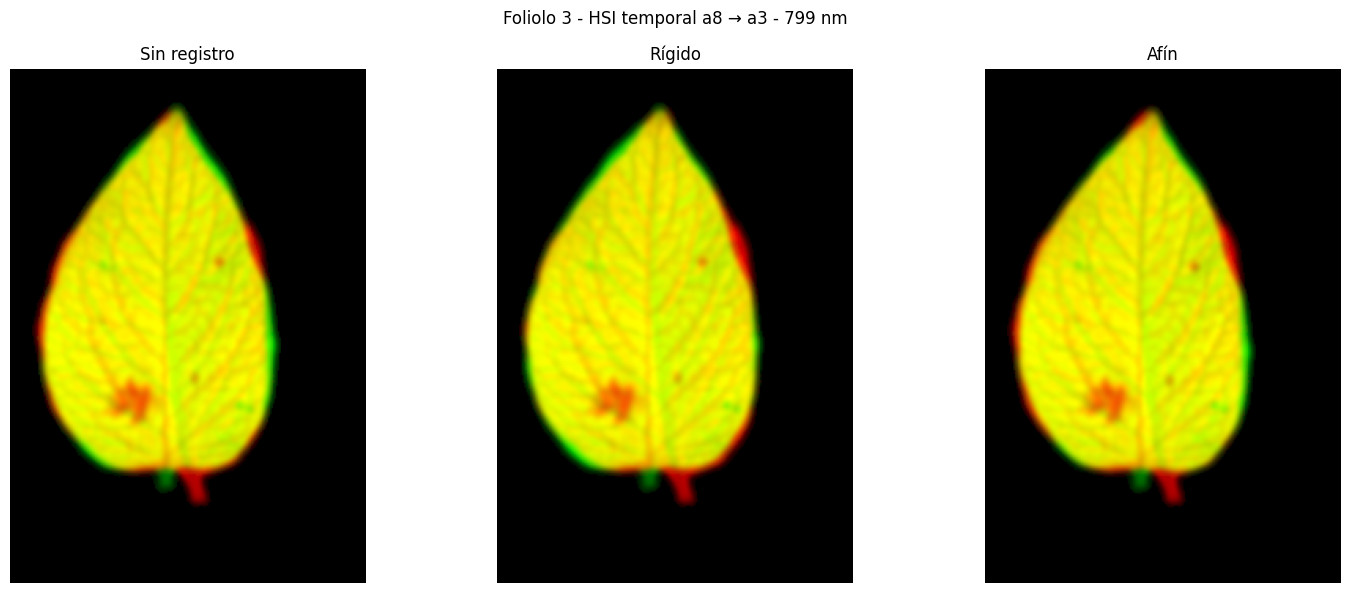

In [ ]:
overlay_affine = np.dstack([
    fixed_np,
    affine_np,
    np.zeros_like(fixed_np)
])

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(overlay_antes)
axes[0].set_title('Sin registro')

axes[1].imshow(overlay_rigido)
axes[1].set_title('Rígido')

axes[2].imshow(overlay_affine)
axes[2].set_title('Afín')

for ax in axes:
    ax.axis('off')

plt.suptitle('Foliolo 3 - HSI temporal a8 → a3 - 799 nm')
plt.tight_layout()
plt.show()

In [ ]:
# Transformación afín obtenida
affine = affine_transform.GetNthTransform(0)

# Imagen móvil después del afín
moving_affine = sitk.Resample(
    moving, fixed, affine_transform,
    sitk.sitkLinear, 0.0, moving.GetPixelID()
)

# Malla B-spline inicial
transform_domain_mesh_size = [6, 8]

bspline = sitk.BSplineTransformInitializer(
    fixed,
    transformDomainMeshSize=transform_domain_mesh_size,
    order=3
)

registration_bspline = sitk.ImageRegistrationMethod()

registration_bspline.SetMetricAsMattesMutualInformation(numberOfHistogramBins=50)
registration_bspline.SetMetricSamplingStrategy(registration_bspline.RANDOM)
registration_bspline.SetMetricSamplingPercentage(0.30)

registration_bspline.SetInterpolator(sitk.sitkLinear)

registration_bspline.SetOptimizerAsLBFGSB(
    gradientConvergenceTolerance=1e-5,
    numberOfIterations=150,
    maximumNumberOfCorrections=5,
    maximumNumberOfFunctionEvaluations=1000,
    costFunctionConvergenceFactor=1e7
)

registration_bspline.SetInitialTransform(bspline, inPlace=False)

# Registramos sobre la imagen ya alineada afín
bspline_transform = registration_bspline.Execute(fixed, moving_affine)

print('Métrica final:', registration_bspline.GetMetricValue())
print('Motivo de parada:', registration_bspline.GetOptimizerStopConditionDescription())

Métrica final: -0.8494872886232978
Motivo de parada: LBFGSBOptimizerv4: User requested


In [ ]:
total_transform = sitk.CompositeTransform(2)
total_transform.AddTransform(affine_transform)
total_transform.AddTransform(bspline_transform)

moving_deformable = sitk.Resample(
    moving,
    fixed,
    total_transform,
    sitk.sitkLinear,
    0.0,
    moving.GetPixelID()
)

deformable_np = sitk.GetArrayFromImage(moving_deformable)

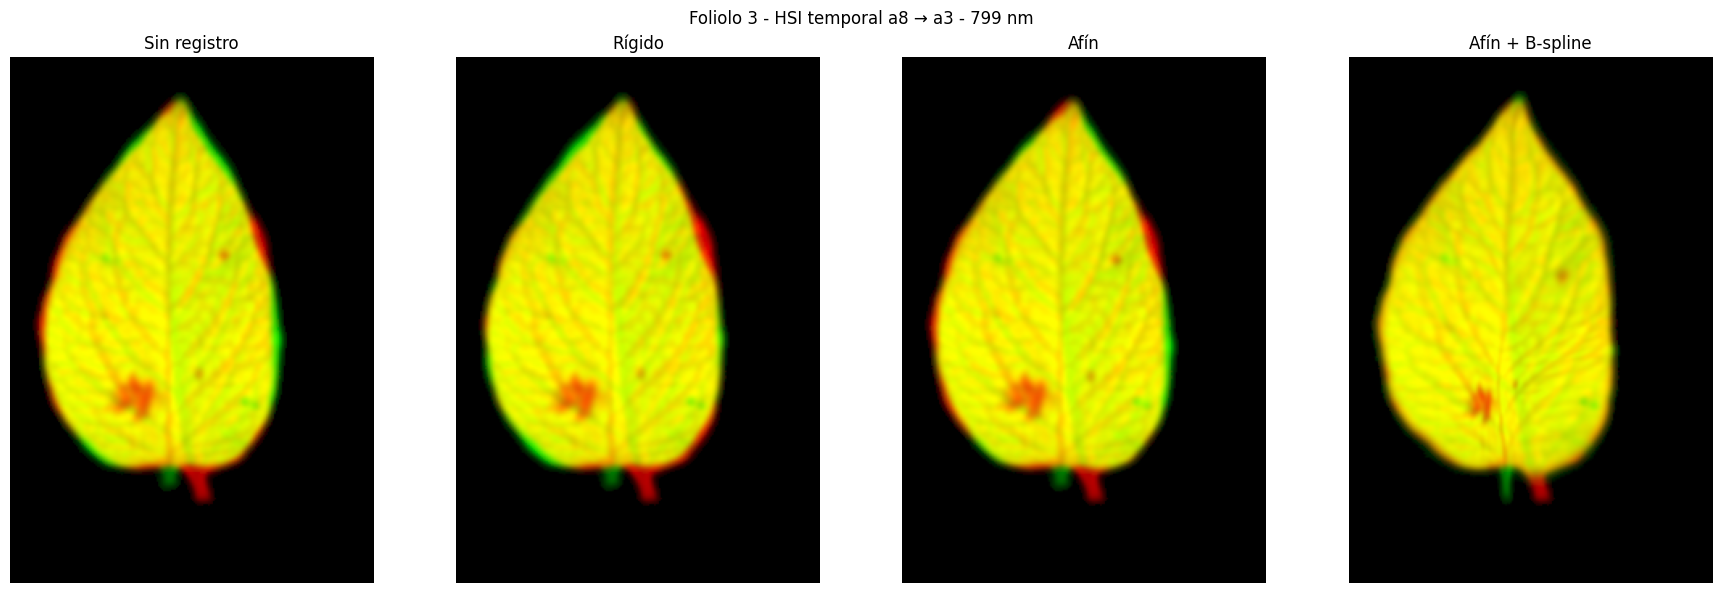

In [ ]:
overlay_deformable = np.dstack([
    fixed_np,
    deformable_np,
    np.zeros_like(fixed_np)
])

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(overlay_antes)
axes[0].set_title('Sin registro')

axes[1].imshow(overlay_rigido)
axes[1].set_title('Rígido')

axes[2].imshow(overlay_affine)
axes[2].set_title('Afín')

axes[3].imshow(overlay_deformable)
axes[3].set_title('Afín + B-spline')

for ax in axes:
    ax.axis('off')

plt.suptitle('Foliolo 3 - HSI temporal a8 → a3 - 799 nm')
plt.tight_layout()
plt.show()

In [ ]:
moving_deformable = sitk.Resample(
    moving_affine,
    fixed,
    bspline_transform,
    sitk.sitkLinear,
    0.0,
    moving_affine.GetPixelID()
)

deformable_np = sitk.GetArrayFromImage(moving_deformable)

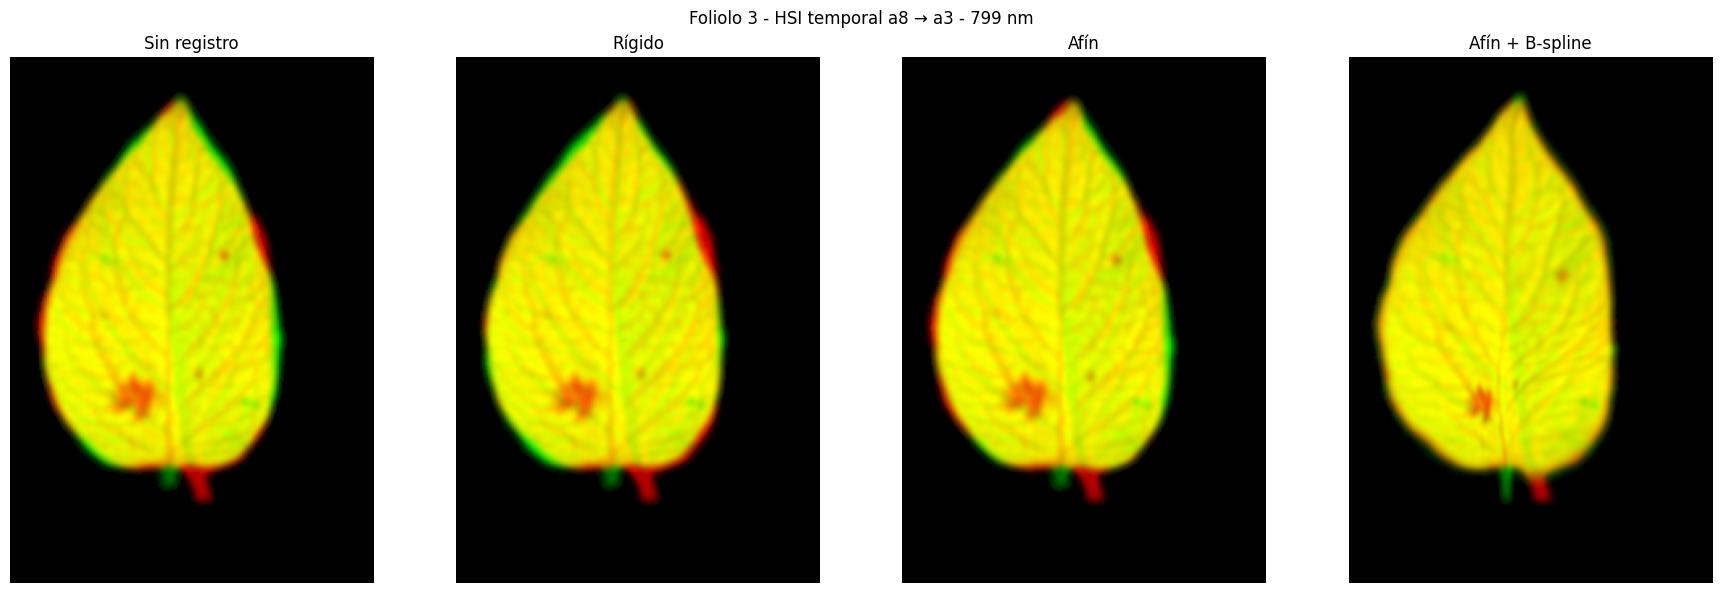

In [ ]:
overlay_deformable = np.dstack([
    fixed_np,
    deformable_np,
    np.zeros_like(fixed_np)
])

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(overlay_antes)
axes[0].set_title('Sin registro')

axes[1].imshow(overlay_rigido)
axes[1].set_title('Rígido')

axes[2].imshow(overlay_affine)
axes[2].set_title('Afín')

axes[3].imshow(overlay_deformable)
axes[3].set_title('Afín + B-spline')

for ax in axes:
    ax.axis('off')

plt.suptitle('Foliolo 3 - HSI temporal a8 → a3 - 799 nm')
plt.tight_layout()
plt.show()

In [ ]:
mask = fixed_np > 0.05

In [ ]:
def ncc_masked(fixed, moving, mask):
    x = fixed[mask].astype(np.float64)
    y = moving[mask].astype(np.float64)

    x -= x.mean()
    y -= y.mean()

    den = np.sqrt(np.sum(x**2) * np.sum(y**2))
    return np.sum(x * y) / den if den > 0 else np.nan

resultados = {
    'Sin registro': ncc_masked(fixed_np, moving_np, mask),
    'Rígido': ncc_masked(fixed_np, rigid_np, mask),
    'Afín': ncc_masked(fixed_np, affine_np, mask),
    'Afín + B-spline': ncc_masked(fixed_np, deformable_np, mask)
}

for metodo, valor in resultados.items():
    print(f'{metodo:18s}: NCC = {valor:.4f}')

Sin registro      : NCC = 0.7759
Rígido            : NCC = 0.7687
Afín              : NCC = 0.7974
Afín + B-spline   : NCC = 0.9177


In [ ]:
def mascara_foliolo(img, threshold=0.05):
    return img > threshold

mask_fixed = mascara_foliolo(fixed_np)

imagenes_eval = {
    'Sin registro': moving_np,
    'Rígido': rigid_np,
    'Afín': affine_np,
    'Afín + B-spline': deformable_np
}

def dice(mask1, mask2):
    inter = np.logical_and(mask1, mask2).sum()
    total = mask1.sum() + mask2.sum()
    return 2 * inter / total if total else np.nan

for metodo, img in imagenes_eval.items():
    d = dice(mask_fixed, mascara_foliolo(img))
    print(f'{metodo:18s}: Dice = {d:.4f}')

Sin registro      : Dice = 0.9656
Rígido            : Dice = 0.9645
Afín              : Dice = 0.9688
Afín + B-spline   : Dice = 0.9829


In [ ]:
displacement = sitk.TransformToDisplacementField(
    bspline_transform,
    sitk.sitkVectorFloat64,
    fixed.GetSize(),
    fixed.GetOrigin(),
    fixed.GetSpacing(),
    fixed.GetDirection()
)

field = sitk.GetArrayFromImage(displacement)

dx = field[:, :, 0]
dy = field[:, :, 1]
magnitud = np.sqrt(dx**2 + dy**2)

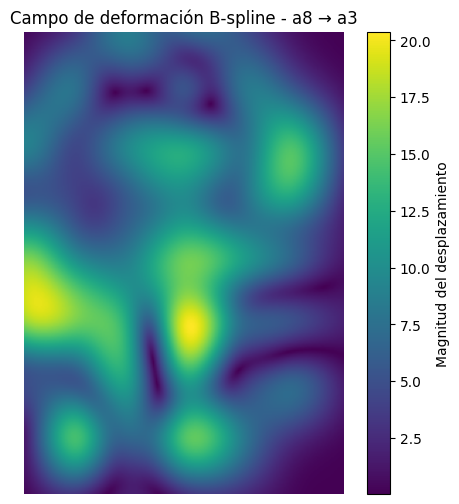

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(magnitud, cmap='viridis')
plt.colorbar(label='Magnitud del desplazamiento')
plt.title('Campo de deformación B-spline - a8 → a3')
plt.axis('off')
plt.show()

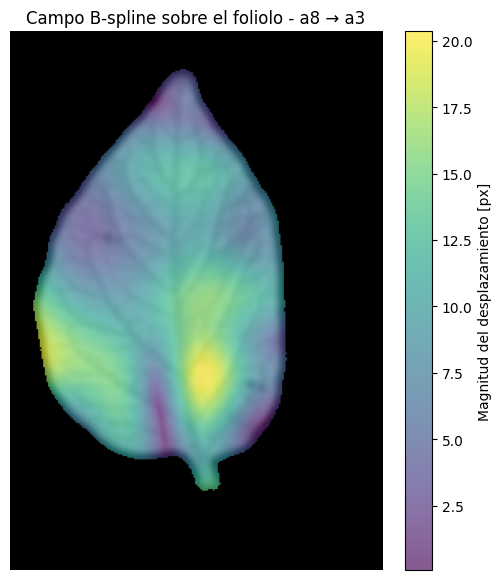

In [ ]:
magnitud_masked = np.where(mask_fixed, magnitud, np.nan)

plt.figure(figsize=(6, 7))
plt.imshow(fixed_np, cmap='gray')
plt.imshow(magnitud_masked, cmap='viridis', alpha=0.65)
plt.colorbar(label='Magnitud del desplazamiento [px]')
plt.title('Campo B-spline sobre el foliolo - a8 → a3')
plt.axis('off')
plt.show()

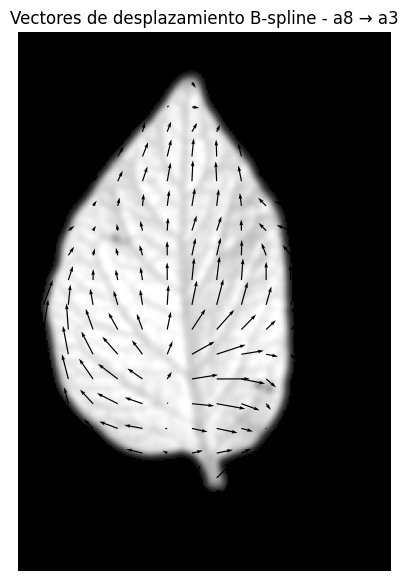

In [ ]:
step = 15
y, x = np.mgrid[0:field.shape[0]:step, 0:field.shape[1]:step]

u = dx[::step, ::step]
v = dy[::step, ::step]

plt.figure(figsize=(6, 7))
plt.imshow(fixed_np, cmap='gray')
plt.quiver(x, y, u, v, angles='xy', scale_units='xy', scale=1)
plt.title('Vectores de desplazamiento B-spline - a8 → a3')
plt.axis('off')
plt.show()

In [ ]:
field_img = sitk.GetImageFromArray(field, isVector=True)

jacobian_img = sitk.DisplacementFieldJacobianDeterminant(field_img)
jacobian = sitk.GetArrayFromImage(jacobian_img)

jac_leaf = jacobian[mask_fixed]

print(f'Jacobiano mínimo: {jac_leaf.min():.4f}')
print(f'Jacobiano máximo: {jac_leaf.max():.4f}')
print(f'Jacobiano medio:  {jac_leaf.mean():.4f}')
print(f'J <= 0:           {(jac_leaf <= 0).sum()} píxeles')

Jacobiano mínimo: 0.3421
Jacobiano máximo: 2.4816
Jacobiano medio:  0.9766
J <= 0:           0 píxeles


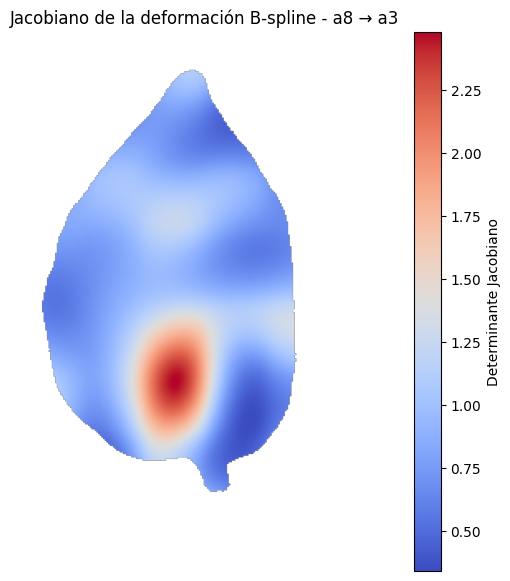

In [ ]:
jac_masked = np.where(mask_fixed, jacobian, np.nan)

plt.figure(figsize=(6, 7))
plt.imshow(jac_masked, cmap='coolwarm')
plt.colorbar(label='Determinante Jacobiano')
plt.title('Jacobiano de la deformación B-spline - a8 → a3')
plt.axis('off')
plt.show()

In [ ]:
def mutual_information(x, y, mask, bins=50):
    x, y = x[mask], y[mask]
    hist, _, _ = np.histogram2d(x, y, bins=bins)
    pxy = hist / hist.sum()
    px = pxy.sum(axis=1)
    py = pxy.sum(axis=0)
    pxpy = px[:, None] * py[None, :]
    nz = pxy > 0
    return np.sum(pxy[nz] * np.log(pxy[nz] / pxpy[nz]))

for metodo, img in imagenes_eval.items():
    print(f'{metodo:18s}: MI = {mutual_information(fixed_np, img, mask_fixed):.4f}')

Sin registro      : MI = 0.3218
Rígido            : MI = 0.3225
Afín              : MI = 0.3412
Afín + B-spline   : MI = 0.6089
